<a href="https://colab.research.google.com/github/lavanyan1105-afk/Brain-Tumor-Detection-using-DeepLearning/blob/main/Brain%20Tumor%20PCA%20XGboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Brain Tumor Classification using XGBoost
This notebook implements different approaches for brain tumor classification:

PCA
VGG16 + XGBoost


In [ ]:
!pip install xgboost seaborn opencv-python

In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

from xgboost import XGBClassifier

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

In [ ]:
dataset_path = "/content/drive/MyDrive/Brain_Tumer"

train_path = dataset_path + "/content/drive/MyDrive/Brain_Tumer/Training"
test_path = dataset_path + "/content/drive/MyDrive/Brain_Tumer/Testing"

In [ ]:
import numpy as np
import os
import cv2

IMG_SIZE = 64

train_data = []
train_labels = []

for category in categories:

    path = os.path.join('/content/drive/MyDrive/Brain_Tumer/Training', category)

    class_num = categories.index(category)

    for img_name in os.listdir(path): # Changed from os.listdir('/content/drive/MyDrive/Brain_Tumer/Training')

        try:
            img_path = os.path.join(path, img_name)

            image = cv2.imread(img_path)

            if image is not None:
                image = cv2.resize(image,(IMG_SIZE,IMG_SIZE))

                train_data.append(image)

                train_labels.append(class_num)

        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

train_data = np.array(train_data)
train_labels = np.array(train_labels)

print("Train Shape:",train_data.shape)

Train Shape: (2870, 64, 64, 3)


In [ ]:
test_data = []
test_labels = []

for category in categories:

    path = os.path.join("/content/drive/MyDrive/Brain_Tumer/Testing", category)

    class_num = categories.index(category)

    for img in os.listdir(path):

        try:
            img_path = os.path.join(path, img)

            image = cv2.imread(img_path)

            image = cv2.resize(image,(IMG_SIZE,IMG_SIZE))

            test_data.append(image)

            test_labels.append(class_num)

        except:
            pass

test_data = np.array(test_data)
test_labels = np.array(test_labels)

print("Test Shape:",test_data.shape)

Test Shape: (394, 64, 64, 3)


In [ ]:
X_train = train_data.reshape(len(train_data), -1)

X_test = test_data.reshape(len(test_data), -1)

y_train = train_labels

y_test = test_labels

In [ ]:
print(X_train.shape)

(2870, 12288)


In [ ]:
pca=PCA(n_components=100)

X_train_pca=pca.fit_transform(X_train)

X_test_pca=pca.transform(X_test)

In [ ]:
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(categories),
    n_estimators=30,
    max_depth=4,
    learning_rate=0.1,
    tree_method="hist"
)

xgb_model.fit(X_train_pca,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=30,
              n_jobs=None, num_class=4, ...)

In [ ]:
pred=xgb_model.predict(X_test_pca)

acc=accuracy_score(y_test,pred)

print("Accuracy:",acc)

Accuracy: 0.6243654822335025


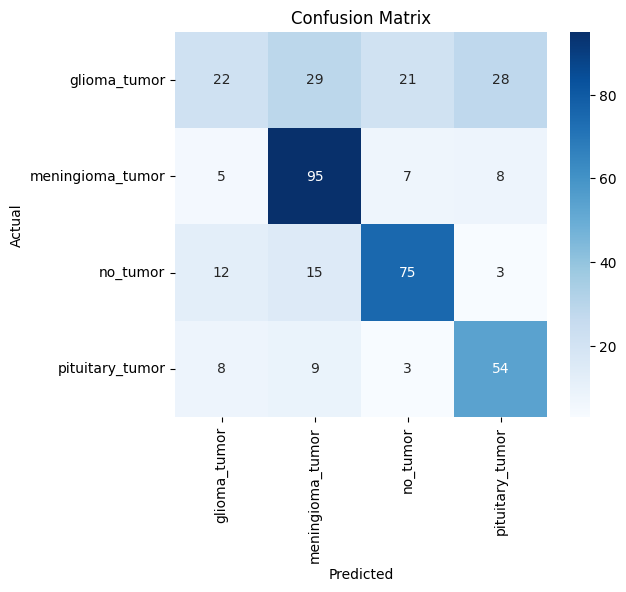

In [ ]:
cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            xticklabels=categories,
            yticklabels=categories)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

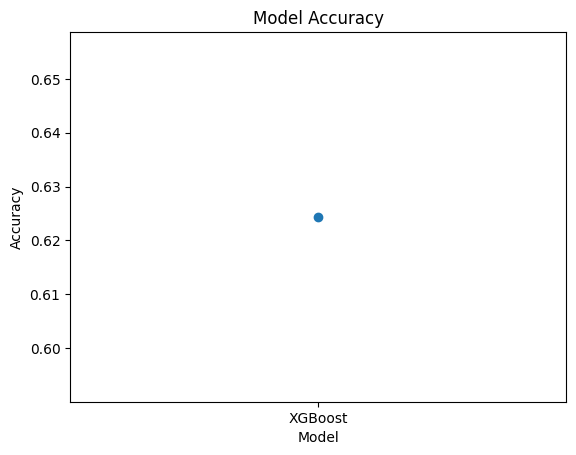

In [ ]:
models=["XGBoost"]

scores=[acc]

plt.plot(models,scores,marker='o')

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.show()

In [ ]:
tree_method="gpu_hist"

In [ ]:
xgb_original = XGBClassifier(
    objective='multi:softmax',
    num_class=len(categories),
    n_estimators=20,
    max_depth=3,
    learning_rate=0.1,
    tree_method="hist"
)

Original XGBoost Accuracy: 0.5152284263959391


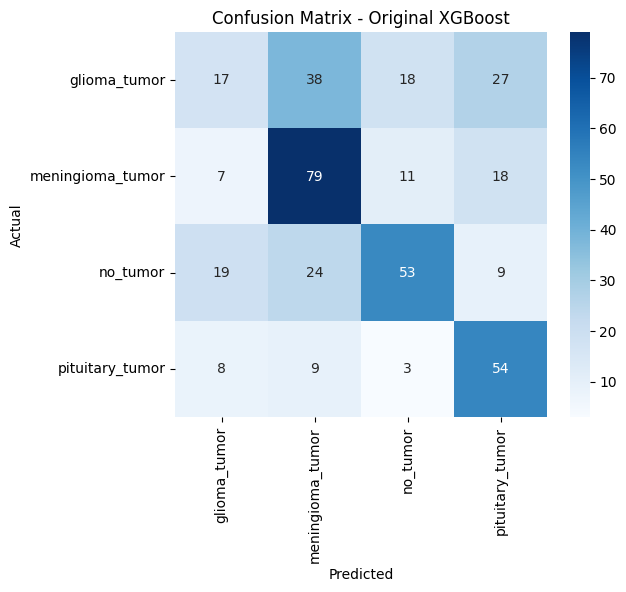

In [ ]:
xgb_original.fit(X_train_pca, y_train)

pred_original = xgb_original.predict(X_test_pca)

acc_original = accuracy_score(y_test, pred_original)

print("Original XGBoost Accuracy:", acc_original)

cm = confusion_matrix(y_test, pred_original)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            xticklabels=categories,
            yticklabels=categories)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Original XGBoost")

plt.show()

In [ ]:
pca = PCA(n_components=100)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
xgb_pca = XGBClassifier(
    objective='multi:softmax',
    num_class=len(categories),
    n_estimators=30,
    max_depth=4,
    learning_rate=0.1,
    tree_method="hist"
)

xgb_pca.fit(X_train_pca, y_train)

pred_pca = xgb_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, pred_pca)

print("PCA + XGBoost Accuracy:", acc_pca)

PCA + XGBoost Accuracy: 0.6015228426395939


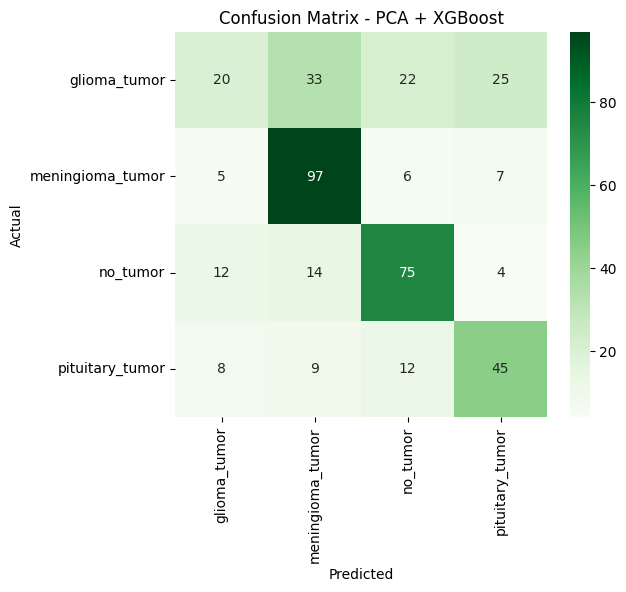

In [ ]:
cm = confusion_matrix(y_test, pred_pca)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            cmap="Greens",
            xticklabels=categories,
            yticklabels=categories)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - PCA + XGBoost")

plt.show()

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

In [ ]:
train_vgg = preprocess_input(train_data.astype("float32"))
test_vgg = preprocess_input(test_data.astype("float32"))

In [ ]:
vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(64,64,3)
)

In [ ]:
train_features = vgg.predict(train_vgg, batch_size=16)
test_features = vgg.predict(test_vgg, batch_size=16)

180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step


In [ ]:
xgb_vgg = XGBClassifier(
    objective='multi:softmax',
    num_class=len(categories),
    n_estimators=30,
    max_depth=4,
    learning_rate=0.1,
    tree_method="hist"
)

# Reshape VGG16 features to 2D
train_features_reshaped = train_features.reshape(train_features.shape[0], -1)
test_features_reshaped = test_features.reshape(test_features.shape[0], -1)

xgb_vgg.fit(train_features_reshaped, y_train)

pred_vgg = xgb_vgg.predict(test_features_reshaped)

acc_vgg = accuracy_score(y_test, pred_vgg)

print("VGG16 + XGBoost Accuracy:", acc_vgg)

VGG16 + XGBoost Accuracy: 0.6598984771573604


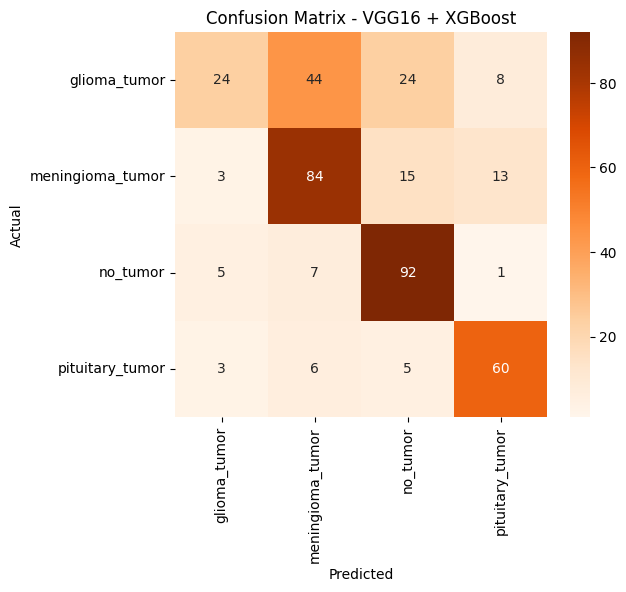

In [ ]:
cm = confusion_matrix(y_test, pred_vgg)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            cmap="Oranges",
            xticklabels=categories,
            yticklabels=categories)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - VGG16 + XGBoost")

plt.show()

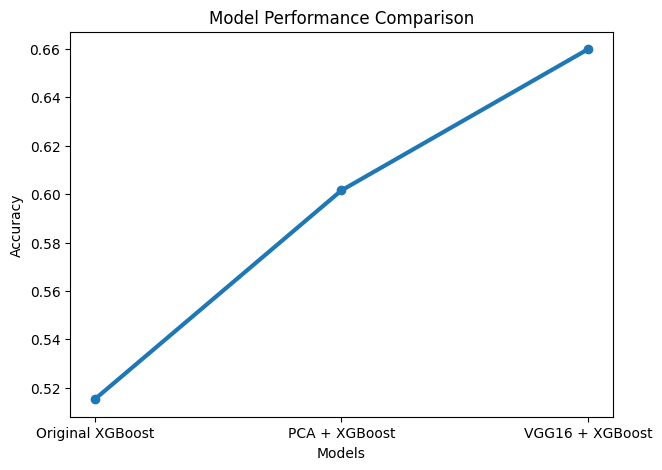

In [ ]:
models = ["Original XGBoost", "PCA + XGBoost", "VGG16 + XGBoost"]

scores = [acc_original, acc_pca, acc_vgg]

plt.figure(figsize=(7,5))

plt.plot(models, scores, marker='o', linewidth=3)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.title("Model Performance Comparison")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

percentages = [0.2,0.4,0.6,0.8]

acc_list=[]

In [ ]:
for p in percentages:

    size=int(len(X_train)*p)

    X_small=X_train[:size]
    y_small=y_train[:size]

    model=XGBClassifier(
        objective='multi:softmax',
        num_class=len(categories),
        n_estimators=30,
        max_depth=4,
        learning_rate=0.1
    )

    model.fit(X_small,y_small)

    pred=model.predict(X_test)

    acc=accuracy_score(y_test,pred)

    acc_list.append(acc)

    print("Training size:",p,"Accuracy:",acc)

Training size: 0.2 Accuracy: 0.25380710659898476
Training size: 0.4 Accuracy: 0.3401015228426396
Training size: 0.6 Accuracy: 0.4416243654822335
Training size: 0.8 Accuracy: 0.631979695431472


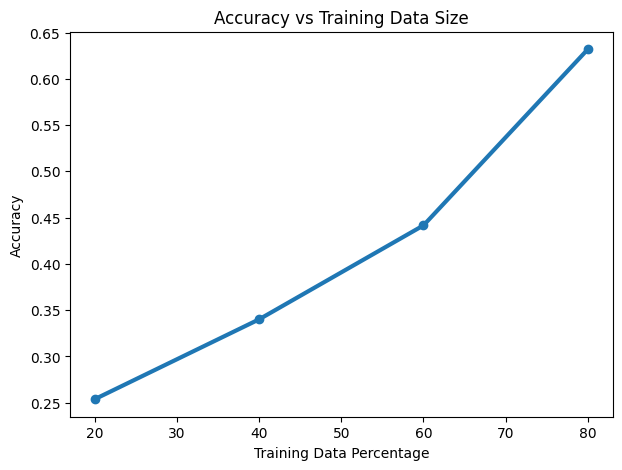

In [ ]:
plt.figure(figsize=(7,5))

plt.plot([20,40,60,80], acc_list, marker='o', linewidth=3)

plt.xlabel("Training Data Percentage")

plt.ylabel("Accuracy")

plt.title("Accuracy vs Training Data Size")

plt.show()